# 10.3 Effective and Optimal Training Strategies
## Reading a training run and deciding what to do next

You have already trained models on this programme. In Unit 6 you met loss, gradients, learning rates and schedules. In Workshop 6 you fine-tuned a network and read its training curves. In 10.1 and 10.2 you built and reasoned about neural architectures.

This notebook does not re-teach any of that. It assumes you can already train a model. The question here is the one that actually fills an engineer's day:

> **A training run is in front of you. What is it telling you, and what should you do about it?**

That question is the whole module. Everything below is a training run behaving badly in a way you need to recognise and act on: a network that will not learn, a learning rate set wrong, a model training itself into overfitting, and a candidate you have to judge before promotion. Reading those signals and choosing the right response is the skill this module builds.

The work is set in a kind of problem every operations team meets: **request triage**, where incoming items have to be sorted by urgency so the important ones are not stuck behind the trivial ones. The specific case is one you already know from this programme, the leaseholder maintenance triage system that Ada Lovelace-Tensori built for **Spender Views RTM Company Limited**. Spender Views receives a few hundred maintenance requests a year, and each one needs an urgency band so that a gas leak is not sitting in a queue behind a dripping tap. The diagnostics you practise here transfer directly to any triage or classification model you build for your own project.

**What you need:** any environment that can run PyTorch on a CPU. You do **not** need a GPU. Every model here is small enough to train in seconds. The execution route for this programme is confirmed separately; a local install, or any hosted CPU notebook environment, will run this without changes.

---
## Setup

We use PyTorch for the models, scikit-learn for the data splits and scoring, and NumPy, pandas and matplotlib for everything else. Run this cell first. It pins PyTorch to a single thread so the small models here run quickly and predictably on a CPU.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(1)        # small models: one thread is faster and more predictable on CPU

DEVICE = "cpu"                  # this module runs entirely on CPU; the final section explains why that is the right call
print("PyTorch:", torch.__version__, "| device:", DEVICE)

PyTorch: 2.11.0+cpu | device: cpu


---
## The data: Spender Views triage requests

Ada's real dataset was anonymised under a DPIA, so we cannot use it directly. Instead we generate a **synthetic stand-in** with the same shape and the same awkward properties she described in her report: a class imbalance (most requests are routine, safety-critical ones are rare) and genuinely hard-to-separate cases, on a modest number of features.

Each request is described by a handful of engineered features of the kind Ada actually used, for example whether safety keywords appear, how long the request text is, and which building system it mentions. The label is the **urgency band**: `0 = Low`, `1 = Medium`, `2 = High`, `3 = Safety-critical`.

We generate a larger sample than Ada's real annual volume so the training runs are statistically stable to read. The real Spender Views volume, a few hundred requests a year, is what we return to for the hardware decision at the end. This is a small tabular classification problem throughout. Hold that thought.

In [2]:
def make_triage_data(n=1500, seed=0):
    rng = np.random.default_rng(seed)
    # Engineered features, loosely mirroring Ada's pipeline.
    safety_kw      = rng.binomial(1, 0.12, n)             # safety keyword present
    text_len       = rng.gamma(3.0, 30.0, n)             # characters in request
    building_sys   = rng.integers(0, 6, n)               # which system (lift, structural, plumbing, electrical, communal, other)
    out_of_hours   = rng.binomial(1, 0.3, n)             # submitted outside working hours
    repeat_request = rng.binomial(1, 0.18, n)            # leaseholder has chased before
    season         = rng.integers(0, 4, n)               # quarter

    # Latent urgency score driving the label, with deliberate noise/overlap.
    score = (
        3.2 * safety_kw
        + 0.9 * (building_sys == 0)            # lift faults skew urgent
        + 0.9 * (building_sys == 1)            # structural skew urgent
        + 0.5 * out_of_hours
        + 0.4 * repeat_request
        + 0.004 * (text_len - 90)
        + rng.normal(0, 0.8, n)               # irreducible overlap between bands
    )
    q = np.quantile(score, [0.55, 0.82, 0.95])
    y = np.digitize(score, q)                  # 0..3, imbalanced toward Low/Medium

    X = np.column_stack([
        safety_kw, text_len, building_sys, out_of_hours, repeat_request, season
    ]).astype(np.float32)
    cols = ["safety_kw","text_len","building_sys","out_of_hours","repeat_request","season"]
    return pd.DataFrame(X, columns=cols), y.astype(np.int64)

X_df, y = make_triage_data()
print("Synthetic requests generated:", len(X_df))
print("\nUrgency band counts (note the imbalance):")
print(pd.Series(y).map({0:"Low",1:"Medium",2:"High",3:"Safety-critical"}).value_counts())
X_df.head()

Synthetic requests generated: 1500

Urgency band counts (note the imbalance):
Low                825
Medium             405
High               195
Safety-critical     75
Name: count, dtype: int64


,safety_kw,text_len,building_sys,out_of_hours,repeat_request,season
0,0.0,95.418083,0.0,0.0,0.0,0.0
1,0.0,69.876190,1.0,0.0,0.0,2.0
2,0.0,67.672195,1.0,0.0,0.0,0.0
3,0.0,66.058594,1.0,1.0,0.0,1.0
4,0.0,56.253807,5.0,0.0,1.0,0.0


In [3]:
# Standardise features and make train / validation / test splits.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X_df.values
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.40, stratify=y, random_state=0)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=0)

scaler = StandardScaler().fit(X_tr)
to_t = lambda a: torch.tensor(scaler.transform(a), dtype=torch.float32)
Xtr, Xval, Xte = to_t(X_tr), to_t(X_val), to_t(X_te)
ytr = torch.tensor(y_tr); yval = torch.tensor(y_val); yte = torch.tensor(y_te)

print(f"Train {len(ytr)}  |  Validation {len(yval)}  |  Test {len(yte)}")
print("The validation set is the one we read during training. The test set we touch once, at the very end.")

Train 900  |  Validation 300  |  Test 300
The validation set is the one we read during training. The test set we touch once, at the very end.


---
## A reusable training loop

Below is a deliberately plain training loop. It returns the history we will spend the rest of the notebook reading: training loss, validation loss, and the per-layer gradient norms at each epoch. The gradient norms are the signal most dashboards never show you, and they are how you watch a network fail from the inside.

There is nothing clever here. Read it once so you trust what the diagnostics are built on, then move on.

In [4]:
def train(model, epochs=60, lr=0.05, record_grads=True, batch=128, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    n = len(Xtr)
    hist = {"train_loss": [], "val_loss": [], "grad_norms": {}}

    lin_layers = [(name, m) for name, m in model.named_modules() if isinstance(m, nn.Linear)]
    for name, _ in lin_layers:
        hist["grad_norms"][name] = []

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n)
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = lossf(model(Xtr[idx]), ytr[idx])
            loss.backward()
            if record_grads and i == 0:                 # log gradient norms once per epoch
                for name, m in lin_layers:
                    g = m.weight.grad
                    hist["grad_norms"][name].append(g.norm().item() if g is not None else 0.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            hist["train_loss"].append(lossf(model(Xtr), ytr).item())
            hist["val_loss"].append(lossf(model(Xval), yval).item())
    return hist

def plot_curves(hist, title):
    plt.figure(figsize=(6,4))
    plt.plot(hist["train_loss"], label="training error")
    plt.plot(hist["val_loss"], label="validation error")
    plt.xlabel("training progress (epochs)"); plt.ylabel("error (lower is better)")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def plot_grad_norms(hist, title):
    plt.figure(figsize=(6,4))
    for name, vals in hist["grad_norms"].items():
        plt.plot(vals, label=name)
    plt.yscale("log")                                   # log scale: the difference spans a huge range
    plt.xlabel("training progress (epochs)")
    plt.ylabel("learning signal reaching the layer\n(higher is better, log scale)")
    plt.title(title); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Training loop and plotting helpers ready.")

Training loop and plotting helpers ready.


---
# Diagnostic 1 - The network that will not learn

A deep network learns by passing a "this is how wrong you were" signal backwards from its answer to its earliest layers, and each layer nudges itself to do a little better next time. The trouble is that this signal can fade as it travels backwards, like a whisper passed down a long line of people. If it fades to nothing before it reaches the first few layers, those layers never find out they were wrong, so they never improve. The network looks like it is training, but the front of it is frozen.

That fading signal is called the **vanishing gradient problem**, and it is one of the most common reasons a deep network refuses to learn.

Here is a network set up to show it. A colleague has built an eight-layer network and used a particular kind of internal switch, called a **sigmoid**, between every layer. Sigmoid switches happen to weaken the signal each time it passes through one, and with eight of them stacked up, very little survives the journey to the front. Run it and watch the error refuse to fall.

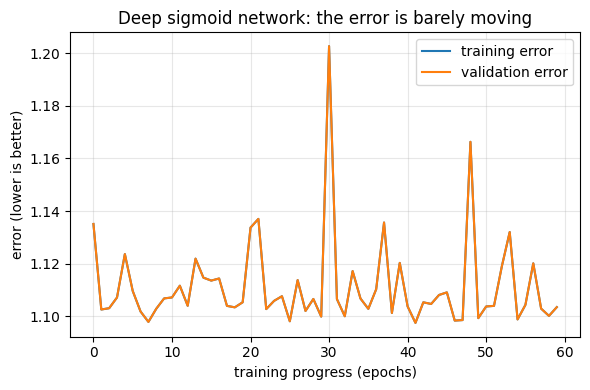

In [17]:
class DeepSigmoid(nn.Module):
    def __init__(self, d_in=6, width=32, depth=16, n_out=4):
        super().__init__()
        layers = [nn.Linear(d_in, width), nn.Sigmoid()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Sigmoid()]
        layers += [nn.Linear(width, n_out)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

h_sig = train(DeepSigmoid(), epochs=60, lr=0.1)
plot_curves(h_sig, "Deep sigmoid network: the error is barely moving")

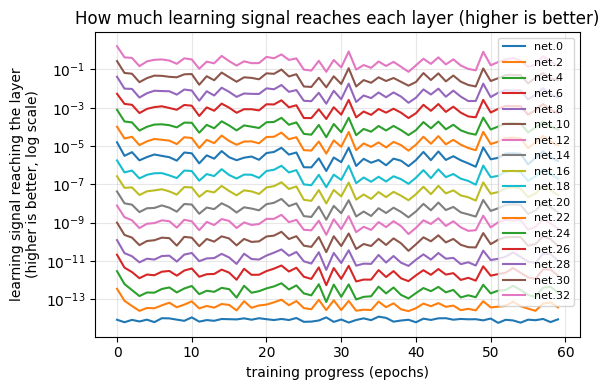

In [18]:
plot_grad_norms(h_sig, "How much learning signal reaches each layer (higher is better)")

**Read it.** The error curve is almost flat: the network is not really learning. The second chart shows why. It measures how much learning signal reaches each layer. The layers nearest the input (`net.0`, `net.2`) are sitting far lower than the layers near the answer, because the signal has faded on its way back through all those sigmoid switches. The early layers are being asked to improve on the basis of almost no information, so they barely move. That is the vanishing gradient problem, happening in front of you rather than described in a textbook.

**The fix.** Swap the sigmoid switches for a different kind, called **ReLU**. A ReLU switch passes the learning signal through at full strength instead of weakening it, so the signal still arrives at the front of the network. Nothing else changes: same depth, same data, same everything. Run it.

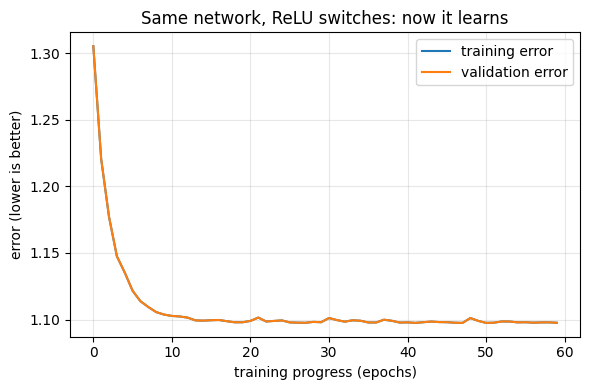

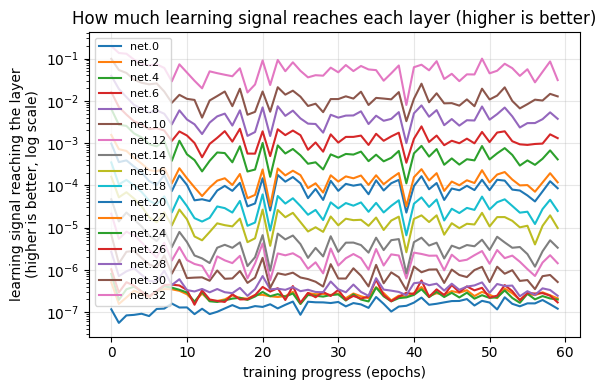

In [19]:
class DeepReLU(nn.Module):
    def __init__(self, d_in=6, width=32, depth=16, n_out=4):
        super().__init__()
        layers = [nn.Linear(d_in, width), nn.ReLU()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.ReLU()]
        layers += [nn.Linear(width, n_out)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

h_relu = train(DeepReLU(), epochs=60, lr=0.1)
plot_curves(h_relu, "Same network, ReLU switches: now it learns")
plot_grad_norms(h_relu, "How much learning signal reaches each layer (higher is better)")

The error falls properly now, and the second chart shows every layer receiving a healthy signal, including the early ones. One change to the kind of switch between layers was the difference between a network that learns and one that does not.

> **Your turn.** Make the sigmoid network deeper by changing `depth` to 16 and re-run. Does the problem get better or worse, and why would more layers make a fading signal worse? Then try the same depth with ReLU. Write one plain sentence you could say to a colleague explaining what you saw.

---
# Diagnostic 2 - Reading the learning rate off the curve

When a network learns, it takes a step toward a better answer after every batch of examples. The **learning rate** is simply how big each step is. You met this idea in Unit 6 as the foggy walker feeling their way downhill: too big a step and they leap over the bottom of the valley, too small and they shuffle forward so slowly they never arrive.

You do not need that idea re-explained. What you need is to **recognise, from the shape of the error curve, when the step size is set wrong**, because that is the actual day-to-day skill. Run the three below and look at them together before reading on.

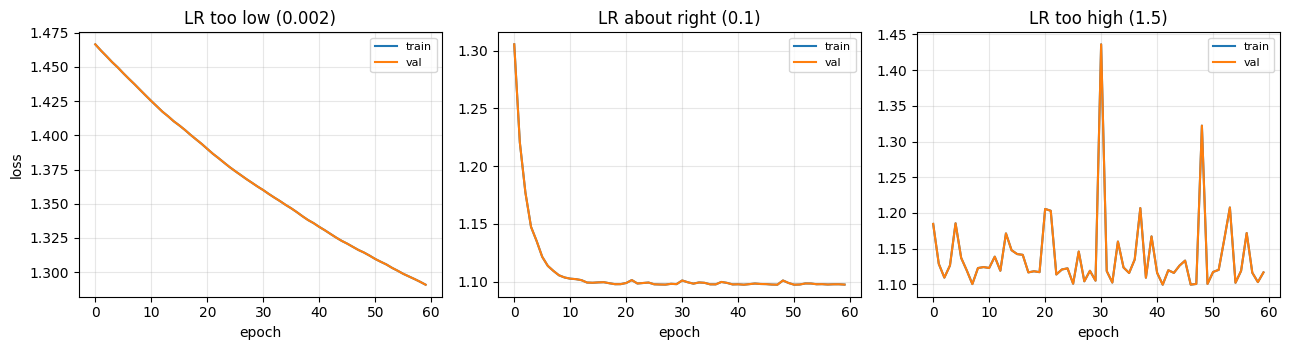

In [20]:
h_low  = train(DeepReLU(), epochs=60, lr=0.002, record_grads=False)
h_high = train(DeepReLU(), epochs=60, lr=1.5,   record_grads=False)
h_ok   = train(DeepReLU(), epochs=60, lr=0.1,   record_grads=False)

fig, ax = plt.subplots(1,3, figsize=(13,3.6))
for a,(h,t) in zip(ax, [(h_low,"LR too low (0.002)"),(h_ok,"LR about right (0.1)"),(h_high,"LR too high (1.5)")]):
    a.plot(h["train_loss"], label="train"); a.plot(h["val_loss"], label="val")
    a.set_title(t); a.set_xlabel("epoch"); a.grid(alpha=0.3); a.legend(fontsize=8)
ax[0].set_ylabel("loss"); plt.tight_layout(); plt.show()

**Read them.**

- **Too low:** the loss falls, but agonisingly slowly. After 60 epochs it is still drifting downward. The model is not broken, it is just wasting your compute budget. The fix is a larger rate, or more patience and more epochs.
- **About right:** a brisk, smooth descent that flattens out. This is what you want to see.
- **Too high:** the loss is jumpy and may even climb. The steps are so large the walker is bouncing across the valley rather than settling into it. The fix is a smaller rate, or a warmup that eases the rate up gently at the start.

**Why a fixed step size is not enough.** Early in training the network is far from a good answer, so big steps make fast progress. Later, when it is close, a big step overshoots and knocks it back out of the good region. So the sensible thing is to **change the step size as training goes on**: take big steps at first, then smaller and smaller steps as the network settles, the way you slow down as you get close to parking a car.

A popular way to do this is called a **cosine schedule**: the step size starts high and eases down along a smooth curve, gentle at the very end so the network can settle precisely rather than bouncing around. It is also common to **warm up** first, starting with a small step for the first few rounds before ramping to the full size, because the very first steps are the most likely to send a fresh, randomly-set network off in a bad direction. PyTorch can do all of this for you with one built-in tool.

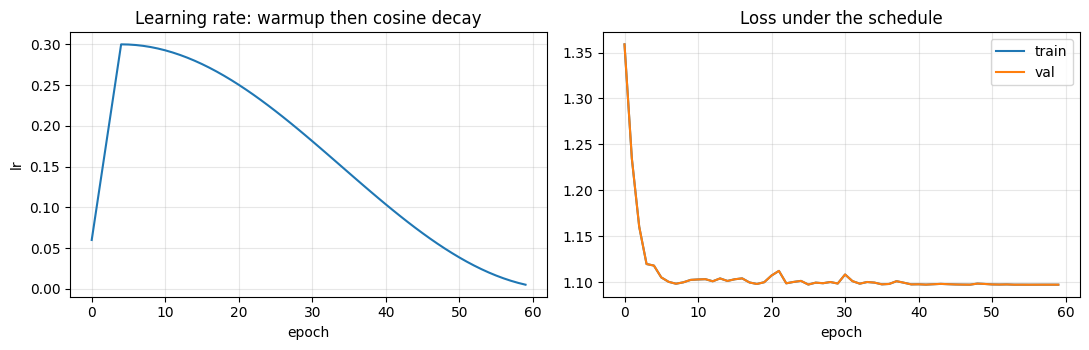

In [21]:
# Cosine decay with a short warmup, using PyTorch's own scheduler.
def train_cosine(model, epochs=60, lr_max=0.3, warmup=5, batch=128, seed=0):
    torch.manual_seed(seed)
    opt = torch.optim.SGD(model.parameters(), lr=lr_max)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    lossf = nn.CrossEntropyLoss()
    n = len(Xtr); hist={"train_loss":[],"val_loss":[],"lr":[]}
    for ep in range(epochs):
        if ep < warmup:                                  # linear warmup, then hand over to cosine
            for g in opt.param_groups: g["lr"] = lr_max * (ep+1)/warmup
        model.train(); perm=torch.randperm(n)
        for i in range(0,n,batch):
            idx=perm[i:i+batch]; opt.zero_grad()
            loss=lossf(model(Xtr[idx]), ytr[idx]); loss.backward(); opt.step()
        if ep>=warmup: sched.step()
        hist["lr"].append(opt.param_groups[0]["lr"])
        model.eval()
        with torch.no_grad():
            hist["train_loss"].append(lossf(model(Xtr),ytr).item())
            hist["val_loss"].append(lossf(model(Xval),yval).item())
    return hist

h_cos = train_cosine(DeepReLU())
fig, ax = plt.subplots(1,2, figsize=(11,3.6))
ax[0].plot(h_cos["lr"]); ax[0].set_title("Learning rate: warmup then cosine decay")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("lr"); ax[0].grid(alpha=0.3)
ax[1].plot(h_cos["train_loss"], label="train"); ax[1].plot(h_cos["val_loss"], label="val")
ax[1].set_title("Loss under the schedule"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

> **CPD link (K18).** In your own words, explain how a cosine-decay schedule helps a model settle near the end of training. Use the landscape picture: what goes wrong if the steps stay large as the walker approaches the valley floor?

---
# Diagnostic 3 - Knowing when to stop

If you let a network train for too long, it stops learning general patterns and starts memorising the exact examples it was shown, including their quirks and mistakes. It is like a student who memorises the answers to last year's exam paper: brilliant on that paper, useless on this year's. You spot it by watching two numbers at once. The error on the **training** examples keeps falling, but the error on a separate set of **validation** examples it has never been trained on stops falling and starts rising. That growing gap between the two is called **overfitting**.

To see it clearly we deliberately set up the conditions that cause it: a network with far more capacity than the problem needs, trained on only a small handful of examples, with a few wrong labels mixed in (real triage data has these, because people sometimes disagree about a request's urgency). Watch the two lines pull apart.

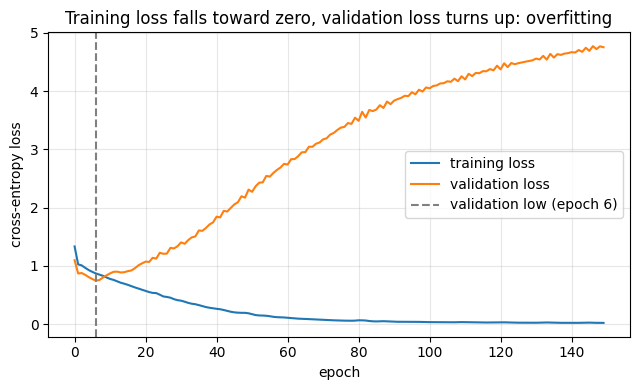

In [22]:
# Force a clean, readable overfitting gap: small training slice + label noise + high capacity.
rng = np.random.default_rng(7)
small_idx = rng.choice(len(Xtr), 180, replace=False)        # only 180 training examples
Xtr_small = Xtr[small_idx]
ytr_small = ytr[small_idx].clone()
flip = rng.choice(len(ytr_small), int(0.15*len(ytr_small)), replace=False)
ytr_small[flip] = torch.tensor(rng.integers(0,4,len(flip)))  # 15% disagreed labels

class WideNet(nn.Module):
    def __init__(self, d_in=6, width=256, n_out=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in,width), nn.ReLU(),
            nn.Linear(width,width), nn.ReLU(),
            nn.Linear(width,n_out))
    def forward(self,x): return self.net(x)

def train_overfit(model, epochs=150, lr=0.01, seed=1):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr); lossf = nn.CrossEntropyLoss()
    tr=[]; vl=[]
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        loss = lossf(model(Xtr_small), ytr_small); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr.append(lossf(model(Xtr_small), ytr_small).item())
            vl.append(lossf(model(Xval), yval).item())
    return tr, vl

tr_o, vl_o = train_overfit(WideNet())
turn = int(np.argmin(vl_o))
plt.figure(figsize=(6.5,4))
plt.plot(tr_o, label="training loss")
plt.plot(vl_o, label="validation loss")
plt.axvline(turn, color="grey", ls="--", label=f"validation low (epoch {turn})")
plt.xlabel("epoch"); plt.ylabel("cross-entropy loss")
plt.title("Training loss falls toward zero, validation loss turns up: overfitting")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Read it.** Training loss drives toward zero as the network memorises its 180 examples, but validation loss bottoms out early and then climbs. Everything to the right of the dashed line is the model getting *worse* at the job you actually care about while looking like it is getting better on the training set. That widening separation is the generalisation gap.

**The fix: stop early, and keep the best version.** Instead of training for a fixed number of rounds, you watch the validation error and stop when it has not improved for a while. The number of rounds you are willing to wait through with no improvement is called the **patience**. And crucially, you do not keep the version of the network from the last round, you keep the version from its *best* round, before the validation error started climbing. That saved best version is called a **checkpoint**. Here is the standard pattern.

Stopped at epoch 5. Best validation loss 0.7643 at epoch 2.


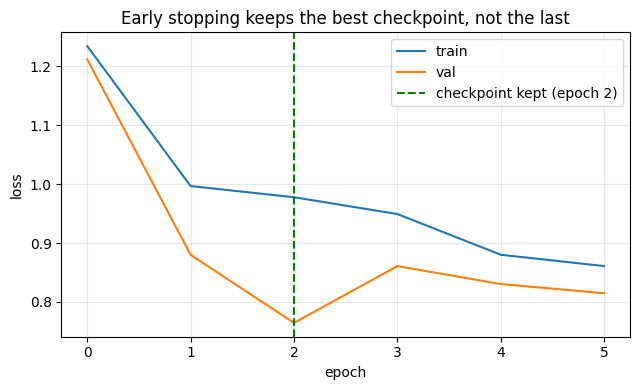

In [31]:
def train_early_stop(model, epochs=150, lr=0.01, patience=3, batch=64, seed=1,
                     Xt=None, yt=None):
    Xt = Xtr_small if Xt is None else Xt
    yt = ytr_small if yt is None else yt
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss(); n=len(Xt)
    best_val=float("inf"); best_epoch=-1; wait=0; best_state=None
    tr_hist=[]; val_hist=[]
    for ep in range(epochs):
        model.train(); perm=torch.randperm(n)
        for i in range(0,n,batch):
            idx=perm[i:i+batch]; opt.zero_grad()
            loss=lossf(model(Xt[idx]),yt[idx]); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr=lossf(model(Xt),yt).item(); vl=lossf(model(Xval),yval).item()
        tr_hist.append(tr); val_hist.append(vl)
        if vl < best_val - 1e-4:                          # improved: record and reset counter
            best_val=vl; best_epoch=ep; wait=0
            best_state={k:v.clone() for k,v in model.state_dict().items()}   # the checkpoint
        else:                                             # no improvement: count toward patience
            wait+=1
            if wait>=patience:
                print(f"Stopped at epoch {ep}. Best validation loss {best_val:.4f} at epoch {best_epoch}.")
                break
    if best_state: model.load_state_dict(best_state)      # restore best weights
    return model, tr_hist, val_hist, best_epoch

m_es, tr_h, val_h, best_ep = train_early_stop(WideNet())
plt.figure(figsize=(6.5,4))
plt.plot(tr_h, label="train"); plt.plot(val_h, label="val")
plt.axvline(best_ep, color="green", ls="--", label=f"checkpoint kept (epoch {best_ep})")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Early stopping keeps the best checkpoint, not the last")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Why record the stopping point.** Ada's report keeps an audit trail for a reason you met in Unit 4: a model that ships today may be replaced in six months, and when a production incident is investigated, "what did the model's validation metrics look like at deployment?" needs an answer in a registry, not in someone's memory. The epoch you stopped at and the validation loss you stopped with are the first entries in that trail.

> **Your turn.** Set `patience=3` and re-run, then `patience=40`. One stops too eagerly on a noisy bump, the other wastes epochs training past the best point. What patience would you defend for this problem, and why?

---
# Diagnostic 4 - Comparing two candidate runs honestly

You now have the moves. The engineering decision is putting them together: given two trained candidates, which do you promote? Two principles from this programme apply. You compare candidates on the **validation** set, the one you are allowed to read repeatedly during development. You confirm the chosen model once on a **frozen test set** you have not tuned against, because every time you peek at the test set to make a decision, it quietly stops being an honest final check.

The fair comparison is between two *competently trained* models, not a good one and a sabotaged one. So we train a sensible moderate-depth network (three hidden layers, ReLU, Adam, early stopped) against a deliberately simple shallow one. To avoid reading too much into a single lucky run, we train each one across several random seeds and look at the *spread* of validation results, not one number. Then, and only then, we touch the test set once.

In [32]:
from sklearn.metrics import f1_score

class DeepCandidate(nn.Module):     # a competent, moderately deep network
    def __init__(self, d_in=6, n_out=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in,64), nn.ReLU(),
            nn.Linear(64,64),   nn.ReLU(),
            nn.Linear(64,32),   nn.ReLU(),
            nn.Linear(32,n_out))
    def forward(self,x): return self.net(x)

class ShallowNet(nn.Module):        # the "simplest thing that might work"
    def __init__(self, d_in=6, n_out=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in,16), nn.ReLU(), nn.Linear(16,n_out))
    def forward(self,x): return self.net(x)

def val_f1(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xval).argmax(1).numpy()
    return f1_score(yval.numpy(), pred, average="macro")

# Train each model across several seeds, on the FULL training set, fairly.
deep_scores, shallow_scores = [], []
for s in range(5):
    d, *_ = train_early_stop(DeepCandidate(), epochs=150, patience=15, seed=s, Xt=Xtr, yt=ytr)
    sh,*_ = train_early_stop(ShallowNet(),    epochs=150, patience=15, seed=s, Xt=Xtr, yt=ytr)
    deep_scores.append(val_f1(d)); shallow_scores.append(val_f1(sh))

deep_scores = np.array(deep_scores); shallow_scores = np.array(shallow_scores)
print(f"\nDeep candidate  macro-F1 across seeds: mean {deep_scores.mean():.3f}, range {deep_scores.min():.3f}-{deep_scores.max():.3f}")
print(f"Shallow network macro-F1 across seeds: mean {shallow_scores.mean():.3f}, range {shallow_scores.min():.3f}-{shallow_scores.max():.3f}")
print(f"\nMean difference (deep - shallow): {deep_scores.mean()-shallow_scores.mean():+.3f}")
print(f"Seed-to-seed swing within the deep model alone: {deep_scores.max()-deep_scores.min():.3f}")
print("\nThe gap between the two models is smaller than the swing you get from changing the seed.")

# Having compared on validation, pick the shallower model (proportionate, and at least as good)
# and confirm it ONCE on the frozen test set. This is the only time we touch the test set.
final_model, *_ = train_early_stop(ShallowNet(), epochs=150, patience=15, seed=0, Xt=Xtr, yt=ytr)
final_model.eval()
with torch.no_grad():
    test_pred = final_model(Xte).argmax(1).numpy()
print(f"\nChosen model (shallow), held-out TEST macro-F1, touched once: {f1_score(yte.numpy(), test_pred, average='macro'):.3f}")

Stopped at epoch 35. Best validation loss 0.6718 at epoch 20.
Stopped at epoch 38. Best validation loss 0.6716 at epoch 23.
Stopped at epoch 39. Best validation loss 0.6650 at epoch 24.
Stopped at epoch 39. Best validation loss 0.6917 at epoch 24.
Stopped at epoch 23. Best validation loss 0.6806 at epoch 8.
Stopped at epoch 52. Best validation loss 0.6666 at epoch 37.
Stopped at epoch 25. Best validation loss 0.6731 at epoch 10.
Stopped at epoch 36. Best validation loss 0.6616 at epoch 21.
Stopped at epoch 22. Best validation loss 0.6711 at epoch 7.
Stopped at epoch 39. Best validation loss 0.6652 at epoch 24.

Deep candidate  macro-F1 across seeds: mean 0.567, range 0.512-0.604
Shallow network macro-F1 across seeds: mean 0.586, range 0.550-0.606

Mean difference (deep - shallow): -0.019
Seed-to-seed swing within the deep model alone: 0.092

The gap between the two models is smaller than the swing you get from changing the seed.
Stopped at epoch 53. Best validation loss 0.6720 at epoch

**Read the result.** Once you average over seeds, the deep candidate and the shallow network score within a few hundredths of an F1 point of each other, and the deep model sometimes *loses*. Crucially, the difference between the two models is **smaller than the swing you get from the deep model alone just by changing the random seed**. When the choice between two architectures is within the noise, the architecture is not the thing making the difference. The deep model is not *wrong*, it is simply **not buying you anything** that justifies its extra size, training instability and serving cost.

This is exactly the reasoning that led Ada to reject a fine-tuned transformer in favour of a gradient-boosted tree: the accuracy gain was about two points of F1, which did not justify the GPU dependency and the loss of explainability. The lesson is not "deep learning loses." It is **proportionality**:

> Decide on the **simplest** model that works. Then justify **why** you didn't choose something more complex.

Every diagnostic you ran is in service of being able to say that with evidence rather than instinct.

---
# The hardware decision (no GPU required to reason about it)

The last engineering call in training is where the model runs. This is a **decision**, not an experiment, and you make it with numbers. Notice that nothing in this notebook needed a GPU: every model trained on a CPU in seconds, because the models are small. That is the same fact that drives the deployment choice.

Ada faced exactly this decision and wrote it down. Her figures (Azure UK South, March 2026):

| Candidate | Instance | Monthly cost | Latency | Notes |
|---|---|---|---|---|
| Gradient-boosted tree (chosen) | B1s, 1 vCPU, CPU | ~£8/mo | 12 ms | SHAP-explainable |
| Fine-tuned DistilBERT (rejected) | NC4as T4, GPU | ~£80/mo | 95 ms | ~2 pts more F1, less explainable |

The decision turns on three quantities you can reason about directly.

**1. Does the model fit, and does it need the cores?** A small tabular network or a gradient-boosted tree has modest weight matrices; a CPU serves them comfortably. A GPU's thousands of cores only pay off for large weight matrices (billion-parameter models) or for many requests batched together. Spender Views has neither.

**2. The latency budget.** A request that runs when a maintenance ticket arrives can take a second or two; a search-as-you-type box cannot. A loose budget lets requests wait briefly to form a batch (the regime where a GPU wins). A tight budget on single requests removes that advantage and a CPU is often competitive. Ada's directors needed predictions to *feel* instant, and 12 ms on a CPU cleared that comfortably.

**3. Cost per request, not cost per hour.** Spender Views receives a few hundred requests a *year*, and the prediction runs once when each request is submitted. Work the volume through in the cell below, using Ada's real annual figure.

In [33]:
# Hardware cost reasoning for the real Spender Views workload.
requests_per_year = 500       # Ada's real volume: 400-600 maintenance requests/year
budget_seconds    = 2.0       # a maintenance ticket can wait a second or two

cpu_cost_month = 8            # GBP, B1s (1 vCPU)
gpu_cost_month = 80           # GBP, NC4as T4
cpu_latency_ms = 12
gpu_latency_ms = 95          # higher here: tiny model, no batch to fill the GPU

per_day = requests_per_year / 365
print(f"Real volume: {requests_per_year} requests/year  (~{per_day:.1f} per day)")
print(f"CPU: GBP {cpu_cost_month}/mo, {cpu_latency_ms} ms per request")
print(f"GPU: GBP {gpu_cost_month}/mo, {gpu_latency_ms} ms per request")
print()
print("At roughly one request per day, the per-hour rate of the box dominates entirely;")
print("the model is idle almost all the time either way.")
print("The GPU costs 10x as much, is slower on a single small request, and is harder to explain.")
print("For this workload the CPU is not just adequate, it is the obviously defensible choice.")

Real volume: 500 requests/year  (~1.4 per day)
CPU: GBP 8/mo, 12 ms per request
GPU: GBP 80/mo, 95 ms per request

At roughly one request per day, the per-hour rate of the box dominates entirely;
the model is idle almost all the time either way.
The GPU costs 10x as much, is slower on a single small request, and is harder to explain.
For this workload the CPU is not just adequate, it is the obviously defensible choice.


The arithmetic is almost trivial here precisely *because* the volume is low: when a model serves one request a day, paying for a GPU is paying for idle silicon. The interesting version of this decision is when volume is high and the latency budget is tight, which is what the distinction task below asks you to reason about.

> **CPD link (K11, S22 - distinction).** Write a short cost-benefit analysis for a deep-learning project in *your own* department, the way Ada did for Spender Views. State the model size, the expected request volume, and the latency budget, then argue for CPU or GPU on the numbers. The mark is not in the answer; it is in whether the numbers carry the argument.

**A useful rule of thumb for the memory question.** At 16-bit precision a model needs roughly 2 GB of GPU memory per billion parameters. A 7-billion-parameter model needs about 14 GB and will not run on a small CPU box at all; a tabular model with a few thousand parameters runs anywhere. Before any latency or cost argument, the first question is always: does the model even fit?

---
## What to take away

You did not learn what a gradient or a learning rate is here. You learned to **read a run and act on it**:

- A flat loss with starved early-layer gradients means **vanishing gradients**. Change the activation.
- A jumpy or crawling loss is a **learning rate** problem. Adjust the rate, or warm up and decay it.
- A widening gap between training and validation loss is **overfitting**. Stop early and keep the best checkpoint, and record where you stopped.
- The choice to promote a model is an **evidence-based comparison against the incumbent** on a frozen set, between candidates that were both trained competently.
- The choice of **hardware** is a written cost-per-request decision, and small models on modest volumes belong on a CPU.

Carry these into your own project. The next workshop will ask you to bring a real training run and put exactly these diagnostics to work on it.